___

<a href='http://www.pieriandata.com'><img src='../Pierian_Data_Logo.png'/></a>
___
<center><em>Авторские права принадлежат Pierian Data Inc.</em></center>
<center><em>Для дополнительной информации посетите наш сайт <a href='http://www.pieriandata.com'>www.pieriandata.com</a></em></center>

# Поиск по сетке

Мы можем перебирать комбинации гиперпараметров с помощью поиска по сетке (grid). Линейные модели достаточно просты, и у них даже есть свои специализированные версии поиска значений параметров. Но также можно использовать обобщённый метод поиска по сетке - grid search. Этот метод применим для *любой* модели в sklearn, и он пригодится нам позже для более сложных моделей.

## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PDF в точке 3: 0.3333333333333333


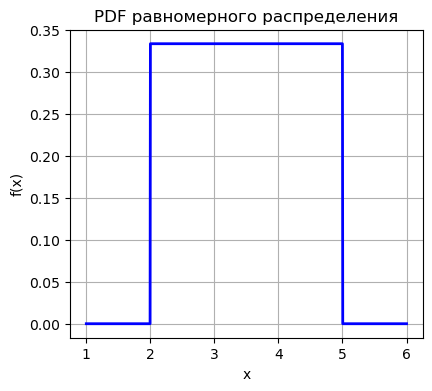

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform

# Создаем равномерное распределение на интервале [2, 5]
rv = uniform(loc=2, scale=3)  # 2 + 3 = 5

x = 3
pdf_value = rv.pdf(x)
print(f"PDF в точке {x}: {pdf_value}")  # 0.333... (1/3)

# Визуализация PDF
x_vals = np.linspace(1, 6, 1000)
pdf_vals = rv.pdf(x_vals)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(x_vals, pdf_vals, 'b-', linewidth=2)
plt.title('PDF равномерного распределения')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)

sns.jointplot(df, )

## Данные

In [2]:
df = pd.read_csv("../DATA/Advertising.csv")

In [3]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


### Форматирование данных

In [4]:
## Создаём X и y
X = df.drop('sales',axis=1)
y = df['sales']

# Разбиение на обучающий и тестовый наборы - TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

# Масштабирование данных (SCALE)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

## Модель

In [5]:
from sklearn.linear_model import ElasticNet

In [9]:
help(ElasticNet)

Help on class ElasticNet in module sklearn.linear_model.coordinate_descent:

class ElasticNet(sklearn.linear_model.base.LinearModel, sklearn.base.RegressorMixin, sklearn.base.MultiOutputMixin)
 |  ElasticNet(alpha=1.0, l1_ratio=0.5, fit_intercept=True, normalize=False, precompute=False, max_iter=1000, copy_X=True, tol=0.0001, warm_start=False, positive=False, random_state=None, selection='cyclic')
 |  
 |  Linear regression with combined L1 and L2 priors as regularizer.
 |  
 |  Minimizes the objective function::
 |  
 |          1 / (2 * n_samples) * ||y - Xw||^2_2
 |          + alpha * l1_ratio * ||w||_1
 |          + 0.5 * alpha * (1 - l1_ratio) * ||w||^2_2
 |  
 |  If you are interested in controlling the L1 and L2 penalty
 |  separately, keep in mind that this is equivalent to::
 |  
 |          a * L1 + b * L2
 |  
 |  where::
 |  
 |          alpha = a + b and l1_ratio = a / (a + b)
 |  
 |  The parameter l1_ratio corresponds to alpha in the glmnet R package while
 |  alpha corr

In [11]:
base_elastic_model = ElasticNet()

## Поиск по сетке - Grid Search

Этот поиск состоит из следующих составляющих:

* функция оценки - estimator (рregressor или classifier, например sklearn.svm.SVC());
* пространство параметров;
* метод поиска или сэмплирования кандидатов;
* схема кросс-валидации
* функция оценки (score function).

In [ ]:
param_grid = {'alpha':[0.1,1,5,10,50,100],
              'l1_ratio':[.1, .5, .7, .9, .95, .99, 1]}

In [12]:
from sklearn.model_selection import GridSearchCV

In [19]:
# число verbose выбирайте сами
grid_model = GridSearchCV(estimator=base_elastic_model,
                          param_grid=param_grid,
                          scoring='neg_mean_squared_error',
                          cv=5,
                          verbose=2)

In [20]:
grid_model.fit(X_train,y_train)

Fitting 5 folds for each of 42 candidates, totalling 210 fits
[CV] alpha=0.1, l1_ratio=0.1 .........................................
[CV] .......................... alpha=0.1, l1_ratio=0.1, total=   0.0s
[CV] alpha=0.1, l1_ratio=0.1 .........................................
[CV] .......................... alpha=0.1, l1_ratio=0.1, total=   0.0s
[CV] alpha=0.1, l1_ratio=0.1 .........................................
[CV] .......................... alpha=0.1, l1_ratio=0.1, total=   0.0s
[CV] alpha=0.1, l1_ratio=0.1 .........................................
[CV] .......................... alpha=0.1, l1_ratio=0.1, total=   0.0s
[CV] alpha=0.1, l1_ratio=0.1 .........................................
[CV] .......................... alpha=0.1, l1_ratio=0.1, total=   0.0s
[CV] alpha=0.1, l1_ratio=0.5 .........................................
[CV] .......................... alpha=0.1, l1_ratio=0.5, total=   0.0s
[CV] alpha=0.1, l1_ratio=0.5 .........................................
[CV] ..........

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s



[CV] alpha=100, l1_ratio=0.1 .........................................
[CV] .......................... alpha=100, l1_ratio=0.1, total=   0.0s
[CV] alpha=100, l1_ratio=0.5 .........................................
[CV] .......................... alpha=100, l1_ratio=0.5, total=   0.0s
[CV] alpha=100, l1_ratio=0.5 .........................................
[CV] .......................... alpha=100, l1_ratio=0.5, total=   0.0s
[CV] alpha=100, l1_ratio=0.5 .........................................
[CV] .......................... alpha=100, l1_ratio=0.5, total=   0.0s
[CV] alpha=100, l1_ratio=0.5 .........................................
[CV] .......................... alpha=100, l1_ratio=0.5, total=   0.0s
[CV] alpha=100, l1_ratio=0.5 .........................................
[CV] .......................... alpha=100, l1_ratio=0.5, total=   0.0s
[CV] alpha=100, l1_ratio=0.7 .........................................
[CV] .......................... alpha=100, l1_ratio=0.7, total=   0.0s
[CV] 

[Parallel(n_jobs=1)]: Done 210 out of 210 | elapsed:    0.1s finished


GridSearchCV(cv=5, error_score='raise-deprecating',
             estimator=ElasticNet(alpha=1.0, copy_X=True, fit_intercept=True,
                                  l1_ratio=0.5, max_iter=1000, normalize=False,
                                  positive=False, precompute=False,
                                  random_state=None, selection='cyclic',
                                  tol=0.0001, warm_start=False),
             iid='warn', n_jobs=None,
             param_grid={'alpha': [0.1, 1, 5, 10, 50, 100],
                         'l1_ratio': [0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1]},
             pre_dispatch='2*n_jobs', refit=True, return_train_score=False,
             scoring='neg_mean_squared_error', verbose=2)

In [21]:
grid_model.best_estimator_

ElasticNet(alpha=0.1, copy_X=True, fit_intercept=True, l1_ratio=1,
           max_iter=1000, normalize=False, positive=False, precompute=False,
           random_state=None, selection='cyclic', tol=0.0001, warm_start=False)

In [22]:
grid_model.best_params_

{'alpha': 0.1, 'l1_ratio': 1}

In [25]:
# pd.DataFrame(grid_model.cv_results_)

## Лучшая модель от поиска по сетке

In [26]:
y_pred = grid_model.predict(X_test)

In [27]:
from sklearn.metrics import mean_squared_error

In [28]:
mean_squared_error(y_test,y_pred)

2.3873426420874737